In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print("Ambiente OK")

Ambiente OK


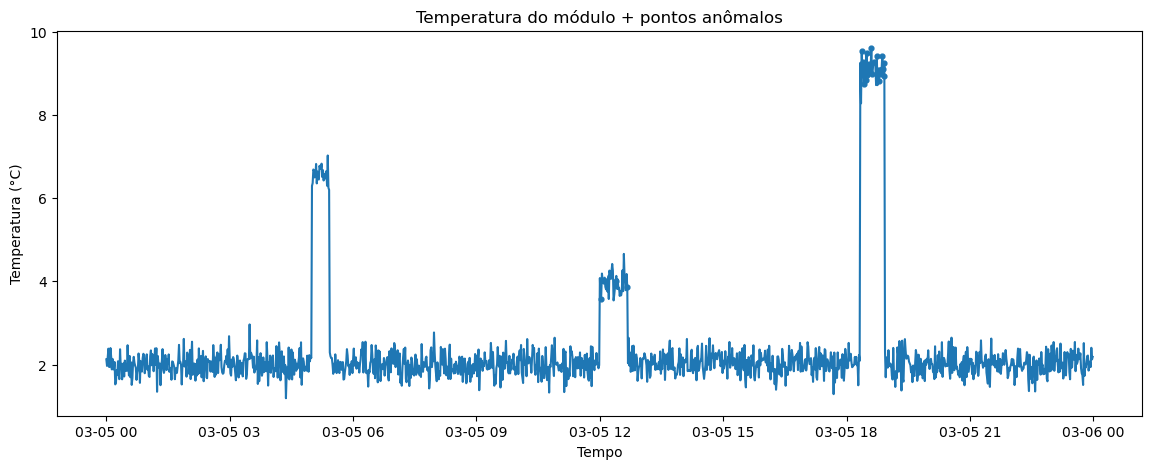

Total de leituras: 1440
Anomalias detectadas: 29 (2.01%)


,ts,temperature_c,current_a,pressure_bar,external_temp_c,anomaly_score
1109,2026-03-05 18:29:00,9.478508,5.217689,15.728885,26.226030,-0.060163
1112,2026-03-05 18:32:00,9.217517,5.174193,15.308579,28.107057,-0.045364
1132,2026-03-05 18:52:00,9.403428,4.740065,15.655252,29.704592,-0.045302
1105,2026-03-05 18:25:00,8.740024,4.886592,15.271265,28.655892,-0.044563
1126,2026-03-05 18:46:00,9.075659,4.600837,15.053463,26.650227,-0.042823
1134,2026-03-05 18:54:00,8.938961,5.324159,15.972326,28.976041,-0.039666
1127,2026-03-05 18:47:00,8.811431,4.930227,15.779540,29.768169,-0.038685
1116,2026-03-05 18:36:00,9.600854,4.272850,15.272766,27.942959,-0.038010
1114,2026-03-05 18:34:00,9.037605,4.626341,15.277221,28.687933,-0.036063
1124,2026-03-05 18:44:00,9.408358,4.620931,15.521600,28.755666,-0.034084


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

n = 24 * 60
ts = pd.date_range("2026-03-05 00:00:00", periods=n, freq="min")

temp = 2.0 + np.random.normal(0, 0.25, n)
current = 4.0 + np.random.normal(0, 0.20, n)
pressure = 18.0 + np.random.normal(0, 0.35, n)
ext_temp = 28.0 + np.random.normal(0, 1.0, n)

df = pd.DataFrame({
    "ts": ts,
    "store_id": "07",
    "asset_id": "ACO-VPHRL-02",
    "module_id": "03",
    "temperature_c": temp,
    "current_a": current,
    "pressure_bar": pressure,
    "external_temp_c": ext_temp
})

def inject_window(start_minute, length, temp_add, current_add=0.0, pressure_add=0.0):
    end = start_minute + length
    df.loc[start_minute:end, "temperature_c"] += temp_add
    df.loc[start_minute:end, "current_a"] += current_add
    df.loc[start_minute:end, "pressure_bar"] += pressure_add

inject_window(300, 25, 4.5)
inject_window(720, 40, 2.0, 1.2, -1.5)
inject_window(1100, 35, 7.0, 0.8, -2.0)

features = ["temperature_c", "current_a", "pressure_bar", "external_temp_c"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(n_estimators=300, contamination=0.02, random_state=42)
pred = model.fit_predict(X_scaled)

df["anomaly_flag"] = (pred == -1).astype(int)
df["anomaly_score"] = model.decision_function(X_scaled)

plt.figure(figsize=(14, 5))
plt.plot(df["ts"], df["temperature_c"])
anoms = df[df["anomaly_flag"] == 1]
plt.scatter(anoms["ts"], anoms["temperature_c"], s=12)
plt.title("Temperatura do módulo + pontos anômalos")
plt.xlabel("Tempo")
plt.ylabel("Temperatura (°C)")
plt.show()

total = len(df)
anom = int(df["anomaly_flag"].sum())
print(f"Total de leituras: {total}")
print(f"Anomalias detectadas: {anom} ({anom/total*100:.2f}%)")

df.sort_values("anomaly_score").head(10)[["ts","temperature_c","current_a","pressure_bar","external_temp_c","anomaly_score"]]